In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"

In [3]:
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
df = pd.read_csv(f'{DATA_DIR}/v1/function_dataset.csv')

In [5]:
X = df.drop(columns=['id', 'label', 'noise'])
y = df['label']
sample_id = df['id']

In [6]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, sample_id, test_size=0.2, random_state=10, stratify=y)

In [7]:
best_model = joblib.load(f'{MODEL_DIR}/v1/best_model.joblib')

In [8]:
y_pred = best_model.predict(X_test)

## 進階錯誤分析

In [9]:
test_all_df = pd.DataFrame({'id': id_test.values,
                            'label': y_test.values,
                            'predicted_label': y_pred})

In [10]:
# 找出 Sine/Cosine 之間的錯誤點
test_df = test_all_df[test_all_df['label'].isin(['sine', 'cosine'])].copy()
test_df['error'] = (test_df['label'] != test_df['predicted_label'])

In [11]:
metadata = pd.read_csv(f'{DATA_DIR}/v1/function_metadata.csv')
metadata = metadata[['id', 'param_1', 'param_2', 'param_3', 'param_4', 'noise_sigma']]

In [12]:
test_metadata = metadata.copy()

In [13]:
# 透過樣本編號對應到 metadata
error_metadata = test_df.merge(metadata, on='id', how='left', validate='one_to_one')
test_df = test_df.merge(test_metadata, on='id', how='left', validate='one_to_one')

In [14]:
# Sine / Cosine 錯誤分析的結果
print(f"樣本數: {len(test_df)}")
print(f"預測錯誤: {test_df['error'].sum()}")
print(f"整體錯誤率: {test_df['error'].mean()}")

樣本數: 200
預測錯誤: 124
整體錯誤率: 0.62


In [15]:
print(f"Sine被誤判成Cosine: {((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum()}")
sine_to_cosine = ((y_test == 'sine') & (y_pred == 'cosine'))
sine_to_cosine_index = X_test.index[sine_to_cosine]
sine_cosine_metadata = error_metadata[(error_metadata['label']=='sine') &
                                      (error_metadata['predicted_label']=='cosine')]
print(sine_cosine_metadata[['id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Sine被誤判成Cosine: 51
  id label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
2663  sine          cosine  0.460904 1.416247  0.907927 -2.727267     0.019535
2966  sine          cosine -0.200000 1.066869 -1.323243 -2.673079     0.007413
2627  sine          cosine  1.158689 2.831358 -1.083610 -1.868983     0.075372
2506  sine          cosine -1.154115 0.777723 -0.302874  2.815742     0.057254
2644  sine          cosine -0.885585 1.818891 -1.371349 -1.684680     0.023654
2625  sine          cosine  0.322383 0.879492 -0.386022 -2.247630     0.018307
2778  sine          cosine  1.223194 0.534191  0.140147 -0.064595     0.083813
2776  sine          cosine -1.791945 2.386604 -0.130682 -0.675790     0.100221
2692  sine          cosine  1.208612 2.867123  0.976202  2.789829     0.059484
2653  sine          cosine  0.200000 1.767097 -0.909911  2.554238     0.006025
2621  sine          cosine  0.653180 1.180576 -0.372666 -2.242137     0.018344
2563  sine          cosine -1.903

In [16]:
print(f"Cosine被誤判成Sine: {((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()}")
cosine_to_sine = ((y_test == 'cosine') & (y_pred == 'sine'))
cosine_to_sine_index = X_test.index[cosine_to_sine]
cosine_sine_metadata = error_metadata[(error_metadata['label']=='cosine') &
                                      (error_metadata['predicted_label']=='sine')]
print(cosine_sine_metadata[['id', 'label', 'predicted_label', 'param_1',
                            'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

Cosine被誤判成Sine: 49
  id  label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
3463 cosine            sine  1.439057 1.735873  0.841242  2.804731     0.037732
3433 cosine            sine  1.408595 1.163773  0.929776  2.248431     0.056615
3014 cosine            sine -1.541312 2.276869  1.449957  0.455172     0.069957
3478 cosine            sine  1.370767 2.253366 -0.756502 -0.420816     0.095815
3157 cosine            sine  1.871582 2.578661 -1.332700  2.031135     0.084216
3123 cosine            sine -1.420432 0.777031 -1.157458  2.314379     0.020380
3474 cosine            sine -0.200000 2.212308 -0.553439 -2.278394     0.004183
3345 cosine            sine  1.457215 2.114699  0.293063  0.642109     0.083261
3481 cosine            sine -1.435573 1.258064 -1.461395 -2.165775     0.028827
3144 cosine            sine -0.440476 0.678888  0.407613 -1.405236     0.024005
3019 cosine            sine -1.796519 1.350759 -1.406757 -0.657017     0.091190
3396 cosine          

In [17]:
# 其他錯誤
others = test_df['error'].sum() - \
    ((test_df['label']=='sine') & (test_df['predicted_label']=='cosine')).sum() - \
    ((test_df['label']=='cosine') & (test_df['predicted_label']=='sine')).sum()
print(f"其他錯誤: {others}")
other_errors = test_df[(test_df['error']) &
    ~(((test_df['label'] == 'sine') & (test_df['predicted_label'] == 'cosine')) |
      ((test_df['label'] == 'cosine') & (test_df['predicted_label'] == 'sine')))]
print(other_errors[['id', 'label', 'predicted_label', 'param_1', 
                    'param_2', 'param_3', 'param_4', 'noise_sigma']].to_string(index=False))

其他錯誤: 24
  id  label predicted_label   param_1  param_2   param_3   param_4  noise_sigma
3078 cosine      reciprocal  0.200000 2.157611  0.766726  1.601685     0.003108
3314 cosine     exponential -1.808636 0.631153  0.200694  2.893016     0.090577
3485 cosine      reciprocal -0.308121 2.243557 -0.088410 -0.728396     0.013249
3307 cosine      reciprocal -0.238406 2.577056  1.568572  0.879601     0.007112
3032 cosine      reciprocal -0.200000 1.176348 -0.620869  0.600740     0.009361
3146 cosine      reciprocal -0.277648 1.203193  0.505659 -1.111041     0.006888
3497 cosine      reciprocal -0.200000 1.613328  0.001321 -0.994849     0.006486
3135 cosine     logarithmic -1.987785 0.526615  1.237952  2.690152     0.103530
2724   sine      reciprocal -0.200000 2.575020  0.519127 -0.617325     0.010448
2605   sine      reciprocal  0.200000 1.417127  0.335287 -1.383275     0.004293
3441 cosine      reciprocal  0.326591 0.664300  0.440084  0.180696     0.017839
2793   sine      reciprocal -0.

In [18]:
# 顯示 Noise 統計
print(f"Sine → Cosine:\n{sine_cosine_metadata['noise_sigma'].describe()}\n")

Sine → Cosine:
count    51.000000
mean      0.047582
std       0.032209
min       0.005112
25%       0.018516
50%       0.043322
75%       0.071502
max       0.120146
Name: noise_sigma, dtype: float64



In [19]:
print(f"Cosine → Sine:\n{cosine_sine_metadata['noise_sigma'].describe()}\n")

Cosine → Sine:
count    49.000000
mean      0.044873
std       0.027997
min       0.004183
25%       0.022170
50%       0.037732
75%       0.070542
max       0.097601
Name: noise_sigma, dtype: float64



In [20]:
bins = [0, 0.02, 0.04, 0.06, 0.08, 0.10, np.inf]      # 將 noise_sigma 分成6個區間
labels = ['0.00 ~ 0.02',
          '0.02 ~ 0.04',
          '0.04 ~ 0.06',
          '0.06 ~ 0.08',
          '0.08 ~ 0.10',
          '0.10+']
test_df['noise_range'] = pd.cut(test_df['noise_sigma'], bins=bins, labels=labels, include_lowest=True)
test_df['error'] = (test_df['label'] != test_df['predicted_label'])     # 判斷是否預測錯誤

In [21]:
# 計算每個 Noise 區間的錯誤率
noise_analysis = test_df.groupby('noise_range', observed=False).agg(total_samples=('error', 'count'),
                                                                    error_count=('error', 'sum'),
                                                                    error_rate=('error', 'mean'))

In [22]:
print(noise_analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))

             total_samples  error_count error_rate
noise_range                                       
0.00 ~ 0.02             63           46     73.02%
0.02 ~ 0.04             51           25     49.02%
0.04 ~ 0.06             29           15     51.72%
0.06 ~ 0.08             27           18     66.67%
0.08 ~ 0.10             20           14     70.00%
0.10+                   10            6     60.00%


C:\Users\user\AppData\Local\Temp\ipykernel_15780\700574041.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


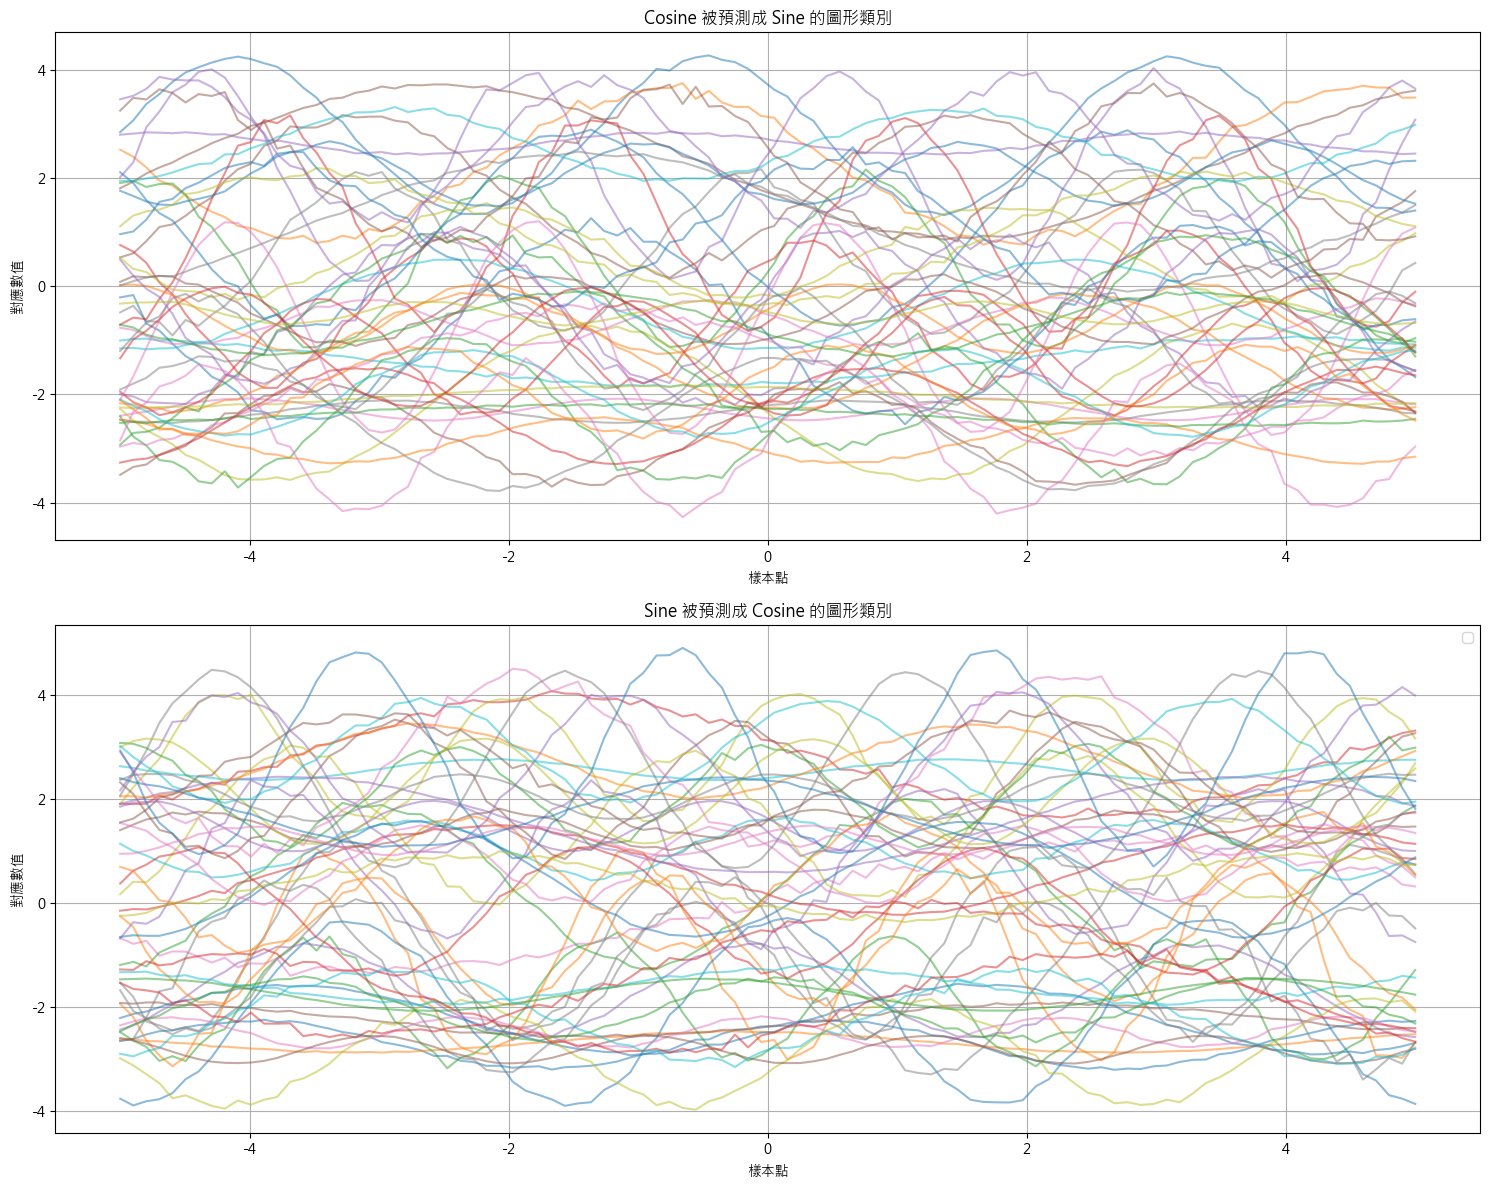

In [23]:
# 繪製圖表
xx = np.linspace(-5, 5, 100)            # Sample Points
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(2, 1, 1)
for index in cosine_to_sine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Cosine 被預測成 Sine 的圖形類別")
ax.grid()

ax = fig.add_subplot(2, 1, 2)
for index in sine_to_cosine_index:
    y_values = X_test.loc[index].values
    ax.plot(xx, y_values, alpha=0.5)
ax.set_xlabel("樣本點")
ax.set_ylabel("對應數值")
ax.set_title("Sine 被預測成 Cosine 的圖形類別")
ax.grid()

plt.tight_layout()
plt.legend()
plt.savefig(f'{DATA_DIR}/v1/advanced_error_analysis.png')
plt.show()

### 參數分析

In [24]:
sine_cosine_parameter_summary = []

In [25]:
parameters = ['param_1', 'param_2', 'param_3', 'param_4']
sine_cosine_parameter_summary = []
for parameter in parameters:
    correct_data = test_df[test_df['error'] == False][parameter]
    error_data = test_df[test_df['error'] == True][parameter]
    sine_cosine_parameter_summary.append({'Parameter': parameter,
                                          'Correct Mean': correct_data.mean(),
                                          'Correct Median': correct_data.median(),
                                          'Error Mean': error_data.mean(),
                                          'Error Median': error_data.median(),
                                          'Mean Difference': (error_data.mean() - correct_data.mean())})
sine_cosine_para_sum_df = pd.DataFrame(sine_cosine_parameter_summary)

In [26]:
print(sine_cosine_para_sum_df.to_string(index=False, 
                                        formatters={'Correct Mean': '{:.3f}'.format,
                                                    'Correct Median': '{:.3f}'.format,
                                                    'Error Mean': '{:.3f}'.format,
                                                    'Error Median': '{:.3f}'.format,
                                                    'Mean Difference': '{:.3f}'.format}))

Parameter Correct Mean Correct Median Error Mean Error Median Mean Difference
  param_1       -0.030         -0.342     -0.099       -0.200          -0.069
  param_2        1.773          1.692      1.734        1.699          -0.039
  param_3        0.043          0.030     -0.059       -0.135          -0.103
  param_4        0.306          0.459     -0.022       -0.364          -0.328


In [27]:
# 儲存參數統計比較
sine_cosine_para_sum_df.to_html(f'{DATA_DIR}/v1/advanced_parameter_results.html')

In [28]:
# 分析每個參數的數值區間
for parameter in parameters:
    # 使用四分位數分組, 每個區間大約包含相同數量的資料
    test_df[f'{parameter}_range'] = pd.qcut(test_df[parameter], q=4, duplicates='drop')
    analysis = test_df.groupby(f'{parameter}_range', observed=False).agg(
        total_samples=('error', 'count'),
        error_count=('error', 'sum'),
        error_rate=('error', 'mean')
    )
    print(analysis.to_string(formatters={'error_rate': '{:.2%}'.format}))
    print("\n")

                               total_samples  error_count error_rate
param_1_range                                                       
(-1.9889999999999999, -0.994]             50           31     62.00%
(-0.994, -0.2]                            59           37     62.71%
(-0.2, 0.97]                              41           28     68.29%
(0.97, 1.953]                             50           28     56.00%


                total_samples  error_count error_rate
param_2_range                                        
(0.511, 1.241]             50           32     64.00%
(1.241, 1.697]             50           29     58.00%
(1.697, 2.296]             50           31     62.00%
(2.296, 2.993]             50           32     64.00%


                  total_samples  error_count error_rate
param_3_range                                          
(-1.569, -0.828]             50           35     70.00%
(-0.828, -0.04]              50           30     60.00%
(-0.04, 0.783]               50   

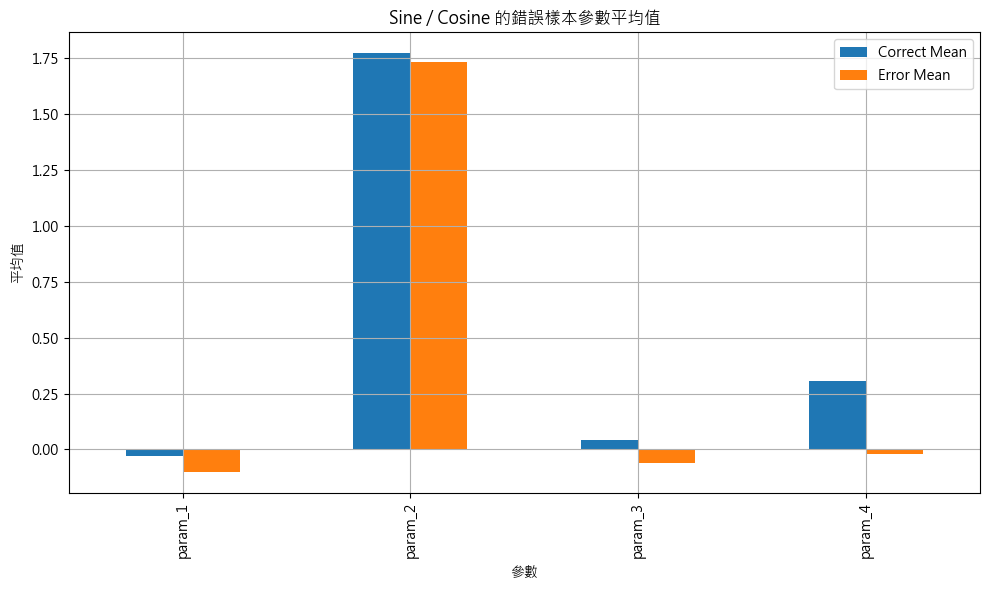

In [29]:
# 繪製圖表(正確/錯誤樣本的參數平均值)
plot_data = sine_cosine_para_sum_df[['Parameter', 'Correct Mean', 'Error Mean']]
plot_data = plot_data.set_index('Parameter')
plot_data.plot(kind='bar', figsize=(10, 6))
plt.xlabel('參數')
plt.ylabel('平均值')
plt.title('Sine / Cosine 的錯誤樣本參數平均值')
plt.xticks()
plt.grid()
plt.tight_layout()
plt.show()